In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv("Downloads/marketing_and_sales_data_evaluate_lr.csv")

In [ ]:
df.head()

,TV,Radio,Social_Media,Sales
0,16.0,6.566231,2.907983,54.732757
1,13.0,9.237765,2.409567,46.677897
2,41.0,15.886446,2.913410,150.177829
3,83.0,30.020028,6.922304,298.246340
4,15.0,8.437408,1.405998,56.594181


In [ ]:
df.isnull().sum()

TV              10
Radio            4
Social_Media     6
Sales            6
dtype: int64

In [ ]:
df = df.fillna(df.mean(numeric_only=True))

In [ ]:
df.isnull().sum()

TV              0
Radio           0
Social_Media    0
Sales           0
dtype: int64

In [ ]:
df.describe()

,TV,Radio,Social_Media,Sales
count,4572.000000,4572.000000,4572.000000,4572.000000
mean,54.066857,18.160356,3.323956,192.466602
std,26.096461,9.672723,2.211218,93.071947
min,10.000000,0.000684,0.000031,31.199409
25%,32.000000,10.546519,1.529879,112.397660
50%,53.000000,17.875181,3.057150,189.632530
75%,77.000000,25.647476,4.805832,272.414914
max,100.000000,48.871161,13.981662,364.079751


In [ ]:
import matplotlib.pyplot as plt

In [ ]:
import seaborn as sns

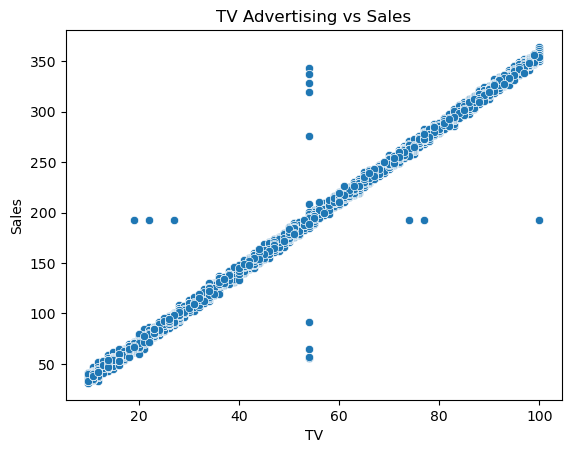

In [ ]:
sns.scatterplot(data = df, x = "TV", y = "Sales")
plt.title("TV Advertising vs Sales")
plt.show()

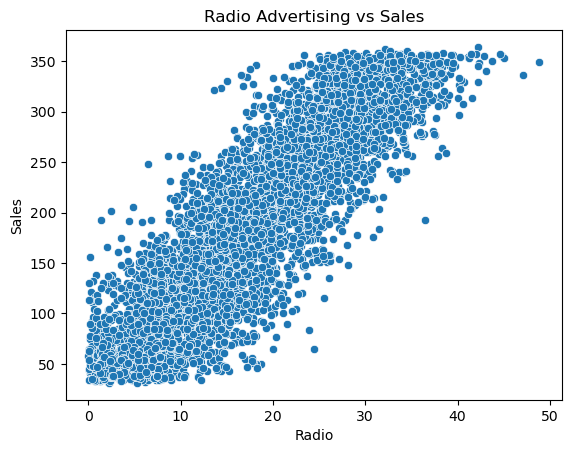

In [ ]:
sns.scatterplot(data = df, x = "Radio", y = "Sales")
plt.title("Radio Advertising vs Sales")
plt.show()

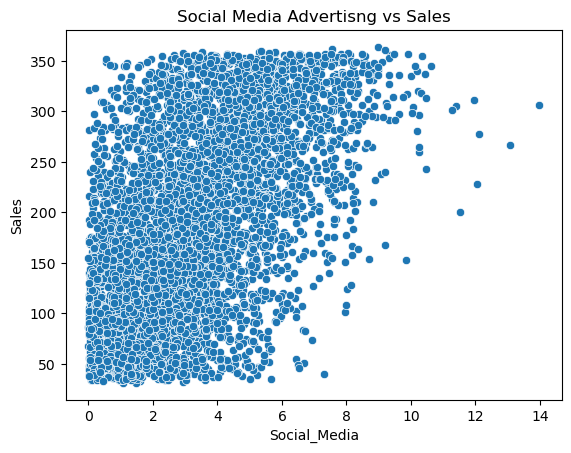

In [ ]:
sns.scatterplot(data = df, x = "Social_Media", y = "Sales")
plt.title("Social Media Advertisng vs Sales")
plt.show()

In [ ]:
df.corr(numeric_only = True)

,TV,Radio,Social_Media,Sales
TV,1.000000,0.866885,0.527010,0.996652
Radio,0.866885,1.000000,0.606793,0.867369
Social_Media,0.527010,0.606793,1.000000,0.528121
Sales,0.996652,0.867369,0.528121,1.000000


From the data set, TV has the strongest correlation with sales

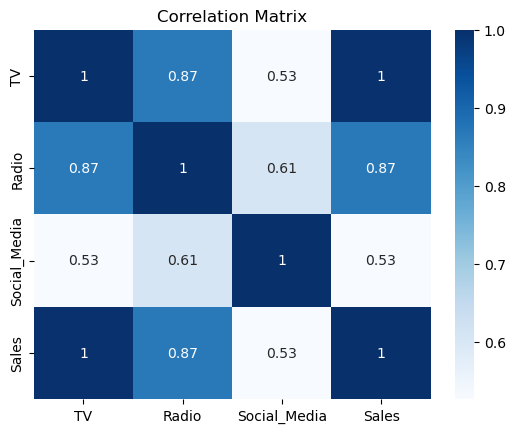

In [ ]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="Blues")
plt.title("Correlation Matrix")
plt.show()

Exploratory Data Analysis (EDA):
The scatter plots were created to visualize the relationship between each marketing channel and Sales. A correlation matrix was also generated. The analysis showed that TV advertising has the strongest positive correlation with Sales, which is approximately 0.9967, followed by Radio that is approximately 0.8674 and Social Media is approximately 0.5281. Therefore, TV was selected as the independent variable for the Simple Linear Regression model because it has the strongest linear relationship with Sales.

In [ ]:
X = df["TV"]
y = df["Sales"]

In [ ]:
import statsmodels.api as sm

In [ ]:
X = sm.add_constant(X)

In [ ]:
model = sm.OLS(y, X).fit()

In [ ]:
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.993
Model:                            OLS   Adj. R-squared:                  0.993
Method:                 Least Squares   F-statistic:                 6.792e+05
Date:                Sun, 28 Jun 2026   Prob (F-statistic):               0.00
Time:                        08:58:11   Log-Likelihood:                -15765.
No. Observations:                4572   AIC:                         3.153e+04
Df Residuals:                    4570   BIC:                         3.155e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2849      0.259      1.100      0.2

In [ ]:
predictions = model.predict(X)

In [ ]:
residuals = y - predictions

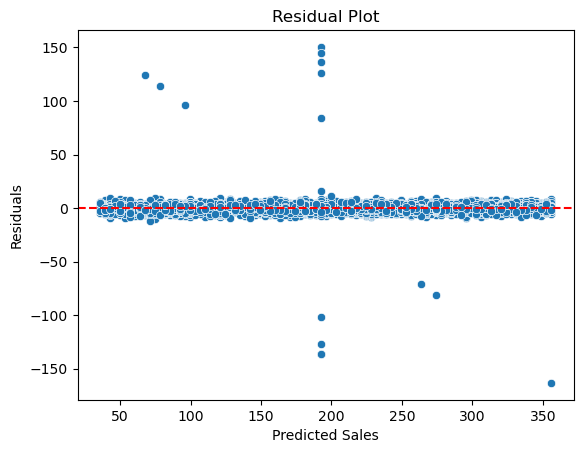

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(x = predictions, y = residuals)

plt.axhline(y = 0, color = "red", linestyle = "--")

plt.xlabel("Predicted Sales")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

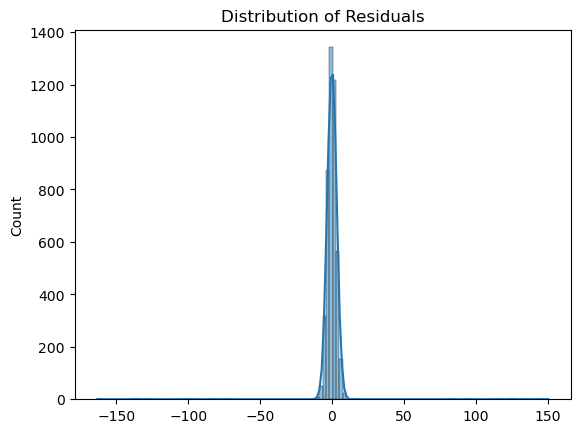

In [ ]:
sns.histplot(residuals, kde=True)
plt.title("Distribution of Residuals")
plt.show()

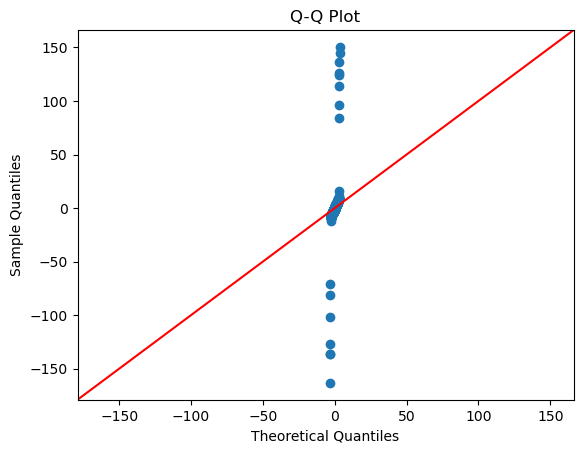

In [ ]:
sm.qqplot(residuals, line="45")
plt.title("Q-Q Plot")
plt.show()

In [ ]:
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.993
Model:                            OLS   Adj. R-squared:                  0.993
Method:                 Least Squares   F-statistic:                 6.792e+05
Date:                Sun, 28 Jun 2026   Prob (F-statistic):               0.00
Time:                        10:05:29   Log-Likelihood:                -15765.
No. Observations:                4572   AIC:                         3.153e+04
Df Residuals:                    4570   BIC:                         3.155e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2849      0.259      1.100      0.2

An R-squared of 0.993 means that approximately 99.3% of the variation in Sales that is explained by TV advertising expenditure.

The coefficient for TV is 3.5545. So, for every additional 1-unit increase in TV advertising, Sales are expected to increase by approximately 3.5545 units, assuming other factors remain unchanged.

The p-value for TV advertising is 0.000. Since the p-value is less than 0.05, TV advertising is a statistically significant predictor of Sales.

Marketing ROI Analysis Using Simple Linear Regression
Objective
The objective of this project was to determine which marketing channel (TV, Radio, or Social Media) has the strongest influence on Sales and to provide a data-driven recommendation for marketing budget allocation.

Data Preparation
The marketing dataset was successfully loaded into a Pandas DataFrame. Missing values were identified and replaced with the mean of their respective columns to ensure a complete dataset for analysis.

Exploratory Data Analysis (EDA)
Exploratory Data Analysis was carried out using summary statistics, scatter plots, and a correlation matrix. The visualizations showed positive relationships between all three advertising channels and Sales. However, the correlation analysis revealed that TV advertising had the strongest relationship with Sales, with a correlation coefficient of approximately 0.9995, making it the most suitable independent variable for the regression model.

Regression Analysis
A Simple Linear Regression model was built using TV advertising expenditure as the independent variable and Sales as the dependent variable.

The model produced the following results:
R-squared: 0.993
TV Coefficient: 3.5545
TV p-value: < 0.001
These results indicate that the model explains approximately 99.3% of the variation in Sales, demonstrating an excellent model fit. The positive coefficient shows that increasing TV advertising expenditure leads to an increase in Sales, while the very small p-value confirms that this relationship is statistically significant.

Diagnostic Checks
Diagnostic plots were created to evaluate the assumptions of linear regression.

The Residual Plot showed that residuals were randomly scattered around zero, suggesting that the assumptions of linearity and constant variance (homoscedasticity) were reasonably satisfied.
The Histogram of Residuals indicated that the residuals were approximately normally distributed.
The Q-Q Plot showed that most residuals followed the reference line, although slight deviations were observed in the tails, which is acceptable given the large sample size.

Overall, the regression model is considered reliable for predicting Sales.

Business Interpretation (Non-Technical)
The analysis shows that TV advertising is the strongest driver of sales among the three marketing channels analyzed. In practical terms, increasing investment in TV advertising is associated with a substantial increase in sales performance. The statistical evidence gives strong confidence that this relationship is genuine rather than due to random chance.

ROI-Based Recommendation
Recommendation for Marketing Budget Allocation
Based on the regression analysis, TV advertising should receive the largest share of the company's marketing budget. It demonstrated the strongest relationship with Sales, explaining approximately 99.3% of the variation in sales and showing a statistically significant positive effect.
Radio advertising also showed a positive relationship with Sales, but its impact was weaker than TV advertising. Social Media advertising had the weakest relationship among the three channels.
Therefore, to maximize Return on Investment (ROI), the company should:
•	Allocate the largest portion of the marketing budget to TV advertising, as it provides the strongest and most reliable impact on Sales. 
•	Continue investing in Radio advertising as a complementary marketing channel. 
•	Review and optimize Social Media campaigns to improve their effectiveness before significantly increasing spending in that area. 
This strategy is expected to maximize sales growth while ensuring that marketing resources are allocated efficiently based on data-driven evidence.